<div style="font-size: 60px; font-weight: bold" align="center">
🐔 La poule qui chante 🍗
</div>
<div style="font-size: 48px;" align="center">
Étude de marché &ndash; Export à l'international
</div>

<div style="font-size: 42px;">
📐 ACP et Clustering
</div>

# Import des librairies et paramètres généraux

In [1]:
import numpy as np
import pandas as pd

In [2]:
import plotly.express as px
import plotly.graph_objs as go

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score, rand_score

In [4]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, ward, fcluster
from plotly.figure_factory import create_dendrogram

In [5]:
data_path = "../data/"

# Chargement des données préparées

In [6]:
df_data = pd.read_csv(data_path + "ready.csv", index_col = 0)
df_data

,Zone,Production,Importation,Exportation,TDI,TAS,Population,Croissance Population,Croissance PIB,Croissance PIB par habitant,PIB,PIB par habitant,NUA,Pop - NUA,PUA,GS,LPI,EDB,Distance
ISO3,,,,,,,,,,,,,,,,,,,
AGO,Angola,41.0,335.0,0.0,0.890957,0.109043,31297155.0,45.037561,-17.007853,-19.824847,1.013532e+05,3238.416118,19800000.0,11497155.0,63.2,58.962480,2.05,41.20205,6510.322
ARE,Émirats arabes unis,47.0,612.0,61.0,1.023411,0.078595,9346870.0,48.300306,9.354948,8.038236,4.270494e+05,45689.032634,200000.0,9146870.0,2.5,80.134659,3.96,81.58883,5249.535
ARM,Arménie,12.0,33.0,0.0,0.733333,0.266667,2909965.0,-1.690039,8.071874,8.257530,1.245794e+04,4281.131507,1400000.0,1509965.0,49.7,65.827944,2.61,73.19187,3434.071
AUS,Australie,1235.0,16.0,39.0,0.013201,1.018977,25119706.0,17.543349,3.056880,1.462323,1.454947e+06,57920.551509,800000.0,24319706.0,3.2,80.996137,3.75,80.70552,16975.460
AUT,Autriche,152.0,114.0,83.0,0.622951,0.830601,8841650.0,6.228298,9.075388,8.546483,4.525823e+05,51187.535062,200000.0,8641650.0,2.3,80.312654,4.03,78.73995,1035.144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USA,États-Unis d'Amérique,22298.0,128.0,3776.0,0.006863,1.195603,335056497.0,9.865276,5.325355,4.428877,2.065652e+07,61650.844422,15900000.0,319156497.0,4.7,70.856532,3.89,83.57395,5838.157
UZB,Ouzbékistan,59.0,7.0,0.0,0.106061,0.893939,32373490.0,17.744157,-14.837336,-16.295528,5.287011e+04,1633.129681,6000000.0,26373490.0,18.4,62.273970,2.58,67.75199,5153.064
VNM,Viet Nam,930.0,162.0,22.0,0.151402,0.869159,96237319.0,12.986708,10.219479,9.005081,3.101065e+05,3222.310015,10500000.0,85737319.0,10.9,64.967558,3.27,68.56869,9208.554


# Standardisation

In [7]:
df_data_std = df_data.copy()
del df_data_std["Zone"]
df_data_std.columns.name = "Features"
df_data_std = pd.DataFrame(StandardScaler().fit_transform(df_data_std), index=df_data_std.index, columns=df_data_std.columns)
df_data_std.describe().T[["mean","std"]].round(2)

,mean,std
Features,,
Production,-0.0,1.0
Importation,-0.0,1.0
Exportation,-0.0,1.0
TDI,-0.0,1.0
TAS,-0.0,1.0
Population,-0.0,1.0
Croissance Population,0.0,1.0
Croissance PIB,0.0,1.0
Croissance PIB par habitant,-0.0,1.0


# ACP : Analyse en Composantes Principales

## Calcul des composantes principales

In [8]:
pca = PCA()
pca

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [9]:
pc_coordinates = pca.fit_transform(df_data_std)
pca

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [10]:
df_pc_coordinates = pd.DataFrame(pc_coordinates, columns=[ f"PC{i+1}" for i in range(df_data_std.columns.size) ], index=df_data_std.index)
df_pc_coordinates.columns.name = "PC"
df_pc_coordinates

PC,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
ISO3,,,,,,,,,,,,,,,,,,
AGO,-3.078308,2.233510,-3.151679,2.001579,3.052205,-0.590686,-1.255401,0.261294,1.490284,-0.082987,-0.287124,-0.227198,0.334290,-0.116792,0.147762,-0.015257,0.026216,-3.203079e-16
ARE,1.313891,-1.906057,0.057044,1.234384,3.516300,-2.370588,0.512420,0.379360,-0.515492,-0.186889,1.063528,0.852011,0.474180,0.328811,0.125480,0.033448,0.123128,-8.525949e-18
ARM,-1.003586,-0.492568,0.826384,-0.199000,-0.200239,-0.020634,-0.616501,0.321448,1.562598,1.046259,0.089422,0.182439,-0.709070,-0.034099,-0.101684,-0.075899,0.036750,1.526461e-16
AUS,1.194044,-0.789678,-2.017816,-1.432038,0.049137,-1.333800,2.375350,-0.653413,-0.362325,-1.185976,-0.082163,0.245071,-0.652992,-0.011581,0.077127,-0.043991,0.015954,-3.913002e-16
AUT,1.724922,-2.474935,0.126101,-0.432747,0.656255,-0.082173,-0.437313,-0.381620,-0.237942,0.100229,-0.272159,0.220320,-0.182575,0.609441,0.009610,0.025390,-0.010461,4.230507e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USA,9.504905,4.231543,-1.849220,3.241343,-4.205169,-3.782575,-1.303139,-1.328053,0.334566,0.334161,0.121635,-0.715160,-0.788648,-0.337843,1.396454,0.150982,-0.007398,4.020584e-17
UZB,-1.248978,0.792125,-3.417957,-0.443986,0.467265,0.863458,-1.051682,0.600181,0.238035,0.066567,0.592760,-0.202747,-0.088538,-0.068859,0.125126,-0.129825,-0.044814,8.783562e-17
VNM,0.065008,0.182888,0.309541,-0.396071,-0.139234,-0.239732,0.926294,0.719461,-0.305723,-0.567387,0.405738,0.170951,0.217748,0.627016,-0.039030,-0.153663,-0.032572,7.778985e-17


In [11]:
df_join = df_data.join(df_pc_coordinates)
df_join.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 101 entries, AGO to ZMB
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Zone                         101 non-null    str    
 1   Production                   101 non-null    float64
 2   Importation                  101 non-null    float64
 3   Exportation                  101 non-null    float64
 4   TDI                          101 non-null    float64
 5   TAS                          101 non-null    float64
 6   Population                   101 non-null    float64
 7   Croissance Population        101 non-null    float64
 8   Croissance PIB               101 non-null    float64
 9   Croissance PIB par habitant  101 non-null    float64
 10  PIB                          101 non-null    float64
 11  PIB par habitant             101 non-null    float64
 12  NUA                          101 non-null    float64
 13  Pop - NUA                    101 n

In [12]:
df_components = pd.DataFrame(pca.components_, columns=df_data_std.columns, index=df_pc_coordinates.columns)
df_components.round(3)

Features,Production,Importation,Exportation,TDI,TAS,Population,Croissance Population,Croissance PIB,Croissance PIB par habitant,PIB,PIB par habitant,NUA,Pop - NUA,PUA,GS,LPI,EDB,Distance
PC,,,,,,,,,,,,,,,,,,
PC1,0.330,0.187,0.275,0.068,0.170,0.239,-0.178,0.024,0.049,0.352,0.276,0.137,0.285,-0.262,0.204,0.369,0.313,-0.104
PC2,0.287,-0.013,0.110,-0.211,-0.040,0.369,0.156,-0.107,-0.125,0.219,-0.269,0.341,0.354,0.270,-0.311,-0.197,-0.237,0.212
PC3,-0.055,0.078,-0.151,0.158,-0.094,0.144,-0.113,0.627,0.624,-0.009,-0.098,0.169,0.113,0.103,-0.111,-0.068,-0.063,-0.190
PC4,0.160,0.375,0.418,0.421,0.282,-0.210,0.265,0.044,0.016,0.135,-0.042,-0.281,-0.142,0.129,-0.259,-0.059,-0.254,-0.121
PC5,-0.233,0.426,-0.375,0.354,-0.149,0.200,0.418,-0.146,-0.182,-0.146,0.198,0.281,0.126,0.097,0.073,0.167,0.008,-0.091
PC6,-0.193,-0.104,-0.051,0.176,0.669,0.147,-0.340,-0.158,-0.112,-0.295,-0.198,0.272,0.049,-0.066,-0.162,-0.017,-0.036,-0.245
PC7,-0.086,0.193,-0.039,-0.034,0.386,-0.031,0.041,0.160,0.140,-0.107,-0.077,0.009,-0.055,0.208,0.148,0.197,0.159,0.778
PC8,0.007,0.662,-0.194,-0.175,-0.177,-0.049,-0.386,-0.114,-0.052,0.005,-0.365,-0.184,0.047,-0.258,-0.203,-0.076,0.108,0.033
PC9,0.076,-0.072,0.094,0.608,-0.260,0.047,-0.400,-0.124,-0.082,0.039,-0.160,0.019,0.062,0.163,0.416,-0.291,-0.046,0.204


## Variance expliquée par chaque composante principale

In [13]:
df_variance = pd.DataFrame(
    [ pca.explained_variance_, pca.explained_variance_ratio_ ],
    index=["variance","variance_pct"],
    columns = df_pc_coordinates.columns,
).T
df_variance["variance_pct_cumsum"] = np.cumsum(df_variance["variance_pct"])
df_variance

,variance,variance_pct,variance_pct_cumsum
PC,,,
PC1,4.455165e+00,2.450586e-01,0.245059
PC2,4.134820e+00,2.274379e-01,0.472496
PC3,2.180991e+00,1.199665e-01,0.592463
PC4,1.422749e+00,7.825901e-02,0.670722
PC5,1.322832e+00,7.276304e-02,0.743485
PC6,1.074488e+00,5.910276e-02,0.802588
PC7,8.523595e-01,4.688446e-02,0.849472
PC8,7.389748e-01,4.064768e-02,0.890120
PC9,6.275123e-01,3.451663e-02,0.924637


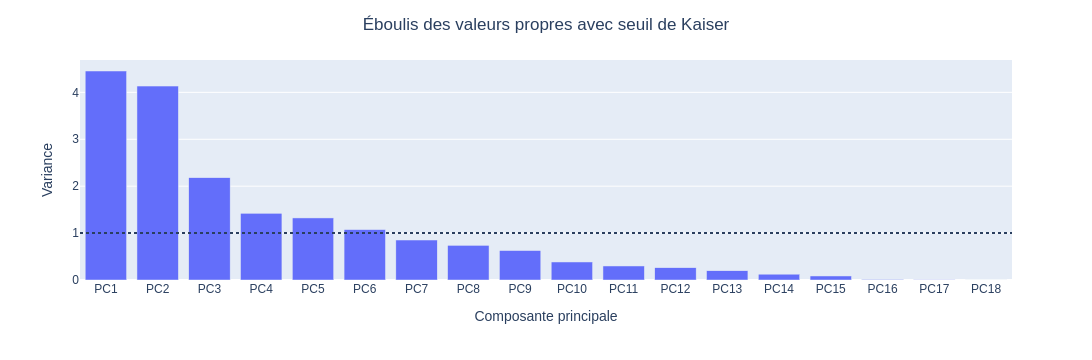

In [14]:
fig = px.bar(
    df_variance, x=df_variance.index, y="variance", hover_data={"variance":":.2f"},
    labels={"PC":"Composante principale","variance":"Variance"},
)
fig.update_layout(yaxis=dict(tickformat=".0f"))
fig.add_hline(y=1, line_dash="dot")
fig.update_layout(title="Éboulis des valeurs propres avec seuil de Kaiser", title_x=0.5)
fig.show()

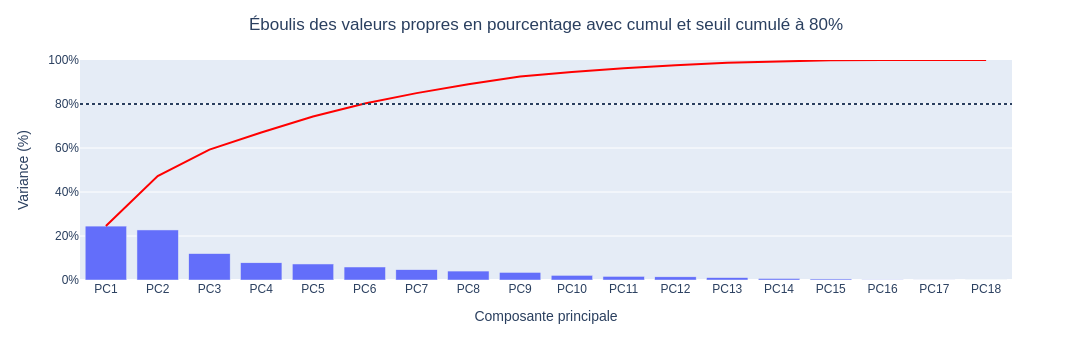

In [15]:
fig = px.bar(
    df_variance, x=df_variance.index, y="variance_pct", hover_data={"variance_pct":":.2%"},
    labels={"PC":"Composante principale","variance_pct":"Variance (%)","variance_pct_cumsum":"Variance cumulée (%)"},
)
fig_line = px.line(df_variance, x=df_variance.index, y="variance_pct_cumsum", hover_data={"variance_pct_cumsum":":.2%"})
fig_line.update_traces(line_color="red")
fig.add_trace(next(fig_line.select_traces()))
fig.update_layout(yaxis=dict(range=(0,1), tickformat=".0%"))
fig.add_hline(y=0.80, line_dash="dot")
fig.update_layout(title="Éboulis des valeurs propres en pourcentage avec cumul et seuil cumulé à 80%", title_x=0.5)
fig.show()

Nombre de composantes principales conservées = **6**
- Cela correspond aux composantes principales avec plus d'information qu'une variable de départ (règle de Kaiser : valeur propre = variance > 1).
- Cela permet de préserver 80% de la variance totale.

In [16]:
# df_data_clustering = df_data_std
# df_data_clustering = df_pc_coordinates
df_data_clustering = df_pc_coordinates.iloc[:,:6]

## Cercles des corrélations

In [17]:
labels = { ind:f"{ind} ({var_pct:.2%})" for ind, var_pct in df_variance["variance_pct"].items() }
labels

{'PC1': 'PC1 (24.51%)',
 'PC2': 'PC2 (22.74%)',
 'PC3': 'PC3 (12.00%)',
 'PC4': 'PC4 (7.83%)',
 'PC5': 'PC5 (7.28%)',
 'PC6': 'PC6 (5.91%)',
 'PC7': 'PC7 (4.69%)',
 'PC8': 'PC8 (4.06%)',
 'PC9': 'PC9 (3.45%)',
 'PC10': 'PC10 (2.11%)',
 'PC11': 'PC11 (1.64%)',
 'PC12': 'PC12 (1.44%)',
 'PC13': 'PC13 (1.08%)',
 'PC14': 'PC14 (0.68%)',
 'PC15': 'PC15 (0.47%)',
 'PC16': 'PC16 (0.07%)',
 'PC17': 'PC17 (0.02%)',
 'PC18': 'PC18 (0.00%)'}

In [18]:
df_loadings = df_components.T * np.sqrt(df_variance["variance"])
df_loadings

PC,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
Features,,,,,,,,,,,,,,,,,,
Production,0.696541,0.583293,-0.081876,0.190592,-0.267968,-0.200461,-0.078943,0.005970,0.060144,-0.010082,0.029577,-0.016244,-0.010666,0.020137,-0.102950,0.085646,0.000350,-4.851858e-32
Importation,0.393690,-0.026193,0.115629,0.447838,0.490208,-0.108208,0.178217,0.568930,-0.056710,0.048597,-0.105379,0.013292,0.098256,-0.080108,0.000699,0.002303,-0.000035,-7.393707e-33
Exportation,0.580926,0.222837,-0.222303,0.498178,-0.431609,-0.052495,-0.036450,-0.167116,0.074776,0.089977,-0.011677,0.272593,0.128019,-0.025912,0.005669,-0.041805,-0.000222,2.194771e-32
TDI,0.143646,-0.428920,0.233215,0.502126,0.407019,0.182511,-0.031565,-0.150116,0.481477,-0.096967,0.110684,0.039288,-0.133878,0.058003,0.006572,0.004475,-0.000532,-1.115097e-32
TAS,0.358930,-0.081574,-0.138698,0.336799,-0.171801,0.693614,0.356441,-0.152580,-0.205608,-0.040725,0.024948,-0.180135,0.025079,-0.056514,-0.004836,0.006865,0.000571,2.037074e-33
Population,0.504194,0.751081,0.212343,-0.250356,0.229654,0.152373,-0.028503,-0.041841,0.037590,-0.041628,0.015246,0.011442,0.025300,-0.000384,-0.030351,-0.017506,0.000068,6.367843e-17
Croissance Population,-0.376300,0.317476,-0.166702,0.316223,0.480921,-0.352732,0.038060,-0.331464,-0.316612,-0.041879,0.249986,-0.022333,0.088231,0.000433,0.001210,0.001916,0.004533,1.275561e-33
Croissance PIB,0.050428,-0.217708,0.925340,0.052965,-0.167712,-0.164248,0.147458,-0.098132,-0.097988,-0.036315,0.022687,0.002459,0.027337,-0.012999,-0.009235,0.000448,-0.045601,-4.684118e-32
Croissance PIB par habitant,0.103114,-0.254845,0.921692,0.019379,-0.209808,-0.116327,0.129508,-0.044703,-0.064845,-0.029761,0.014513,0.013113,0.022926,0.001746,0.001523,0.000595,0.046949,4.616454e-32


In [19]:
def correlation_circle(x: int, y: int):
    assert x in range(1, df_data_std.shape[1]+1), f"Illegal argument: x = {x}"
    assert y in range(1, df_data_std.shape[1]+1), f"Illegal argument: y = {y}"
    assert len({ x, y }) == 2, "Illegal argument combination: not distinct"
    x = f"PC{x}"
    y = f"PC{y}"
    fig = px.scatter(
        df_loadings, x=x, y=y, labels=labels, text=df_loadings.index,
        color_discrete_sequence=["black"], template="plotly_white",
    )
    fig.update_traces(textposition="middle right")
    fig.add_shape(type="circle", xref="x", yref="y", x0=-1, y0=-1, x1=1, y1=1)
    for feature in df_loadings.index:
        fig.add_shape(type="line", x0=0, y0=0, x1=df_loadings.loc[feature,x], y1=df_loadings.loc[feature,y])
    fig.update_layout(
        title=f"Cercle des corrélations sur {x} et {y} (variance expliquée = {df_variance.loc[[x,y],'variance_pct'].sum():.2%})",
        title_x=0.5,
    )
    # fig.update_layout(xaxis=dict(range=(-1,1)))
    # fig.update_layout(yaxis=dict(range=(-1,1), scaleanchor="x", scaleratio=1))
    fig.update_yaxes(range=(-1.1,1.1), scaleanchor="x", scaleratio=1)
    fig.update_layout(width=800, height=750)
    fig.show()

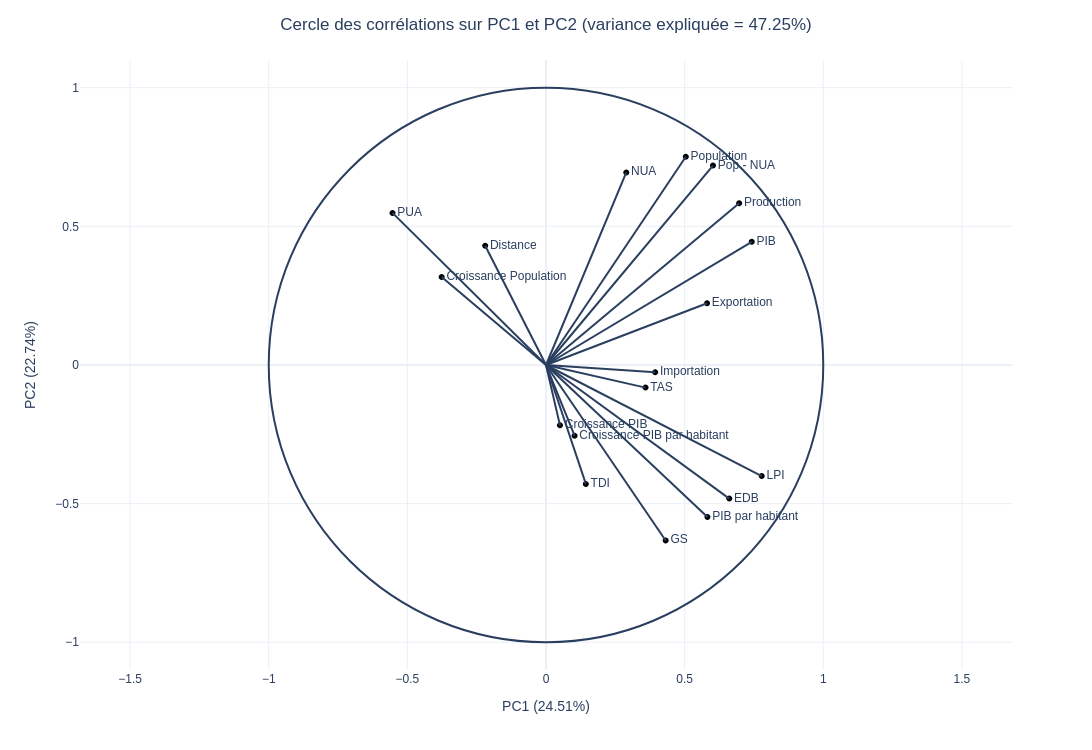

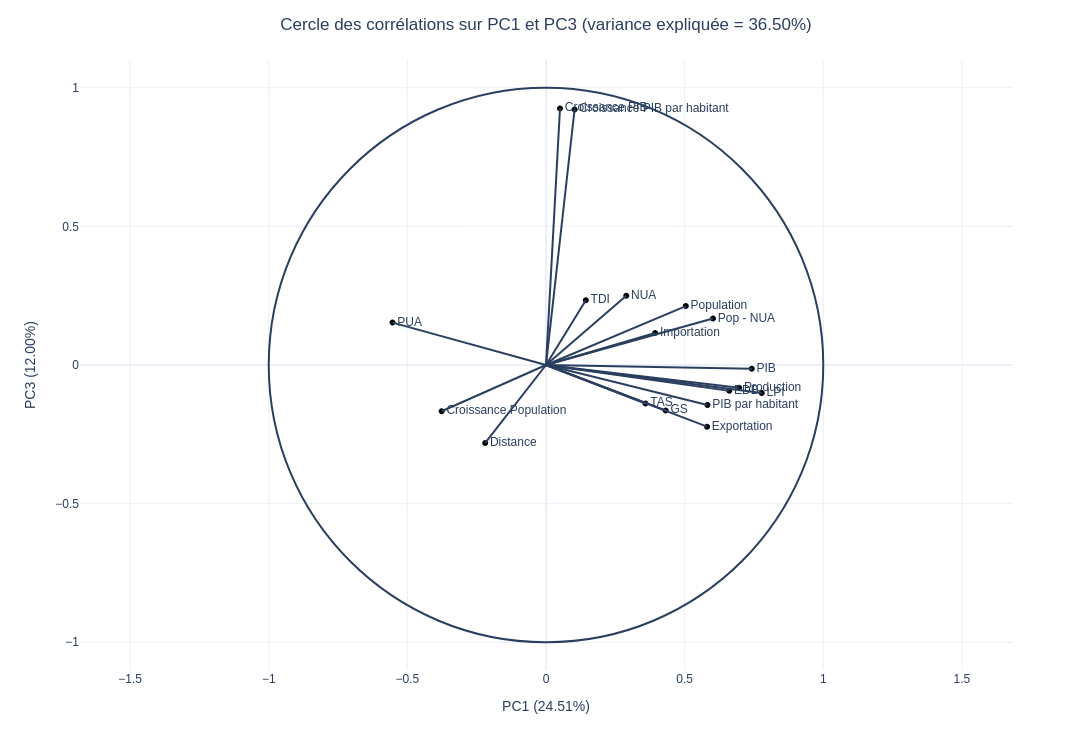

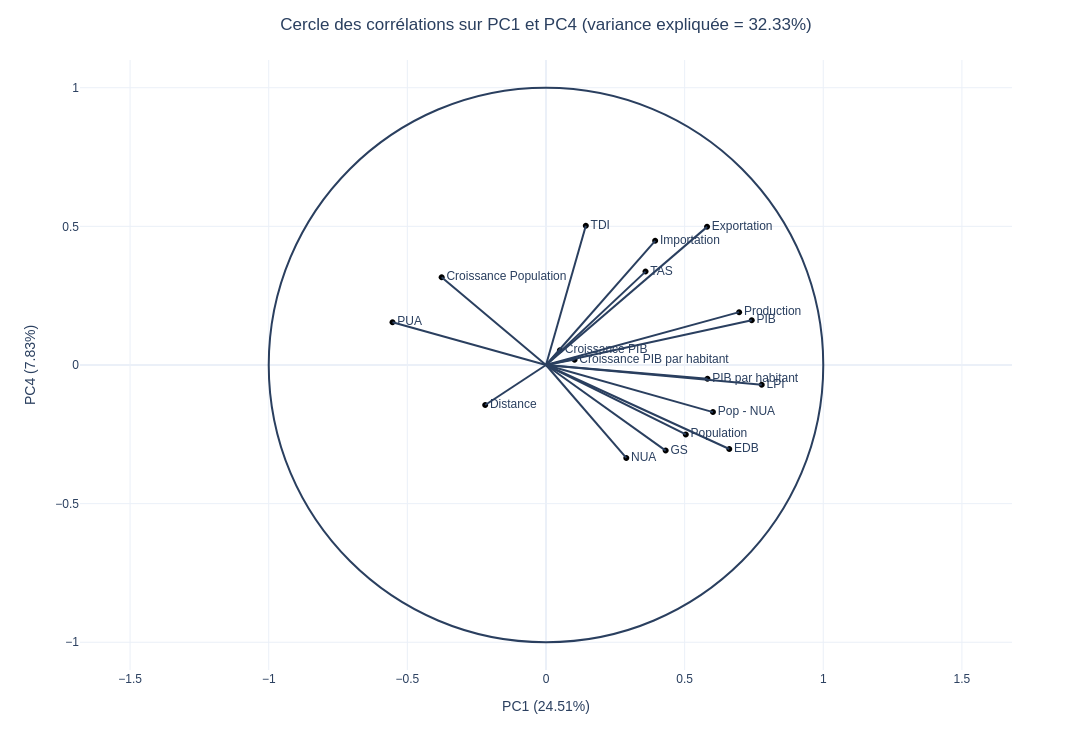

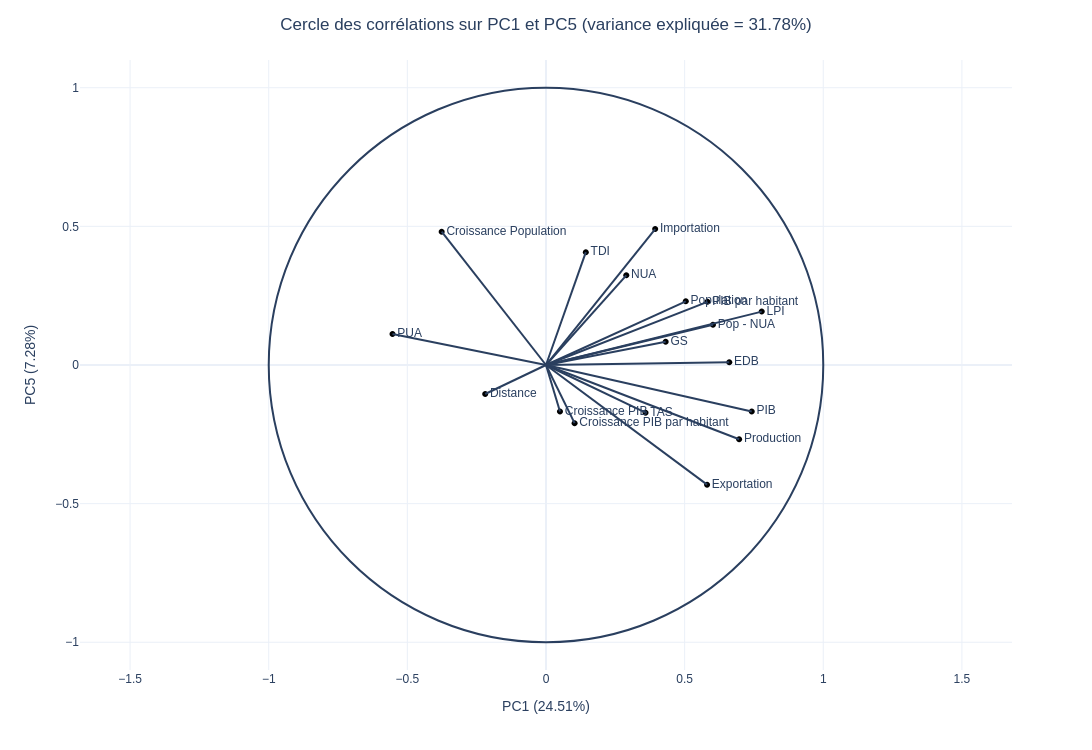

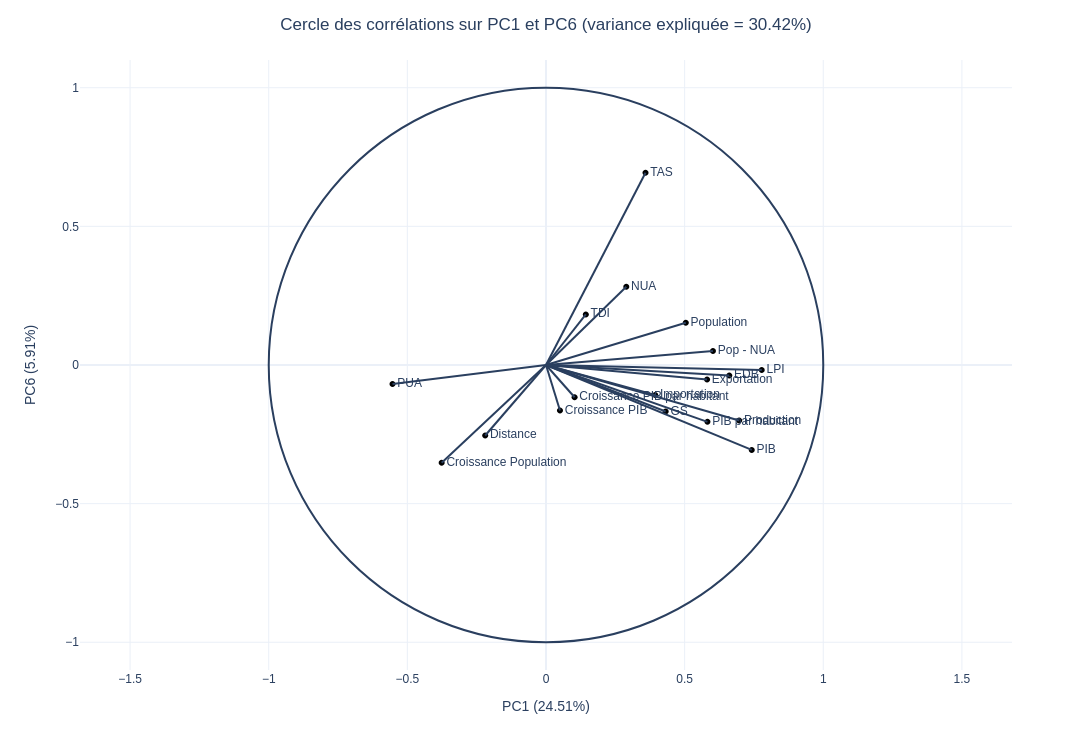

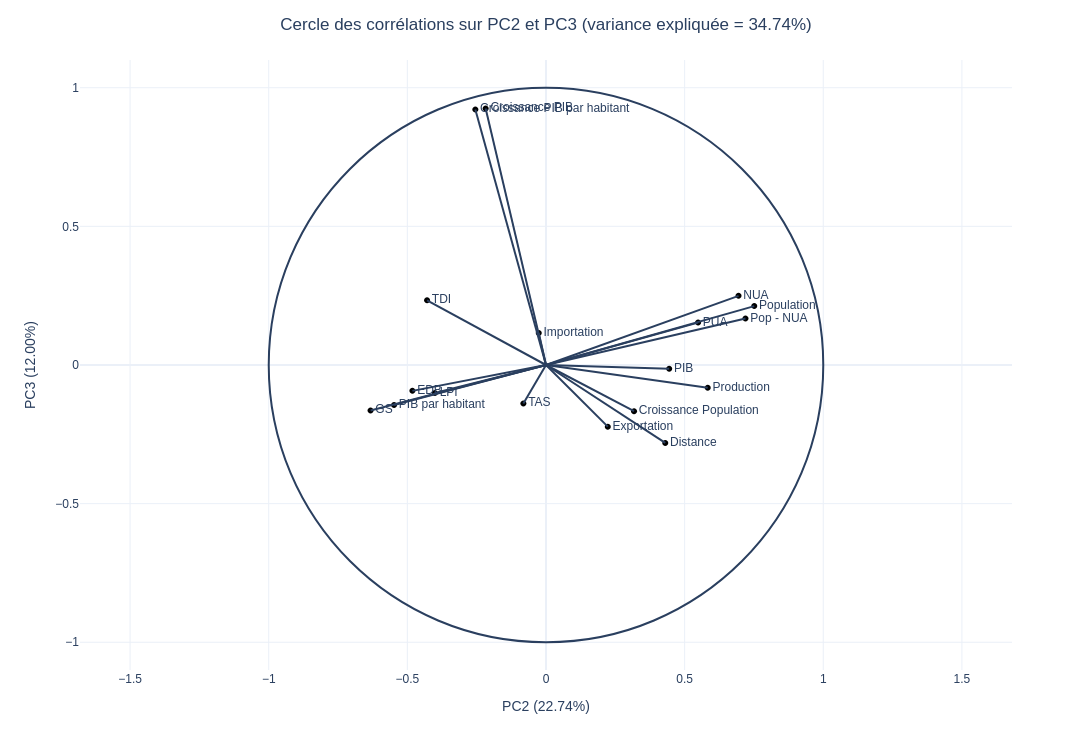

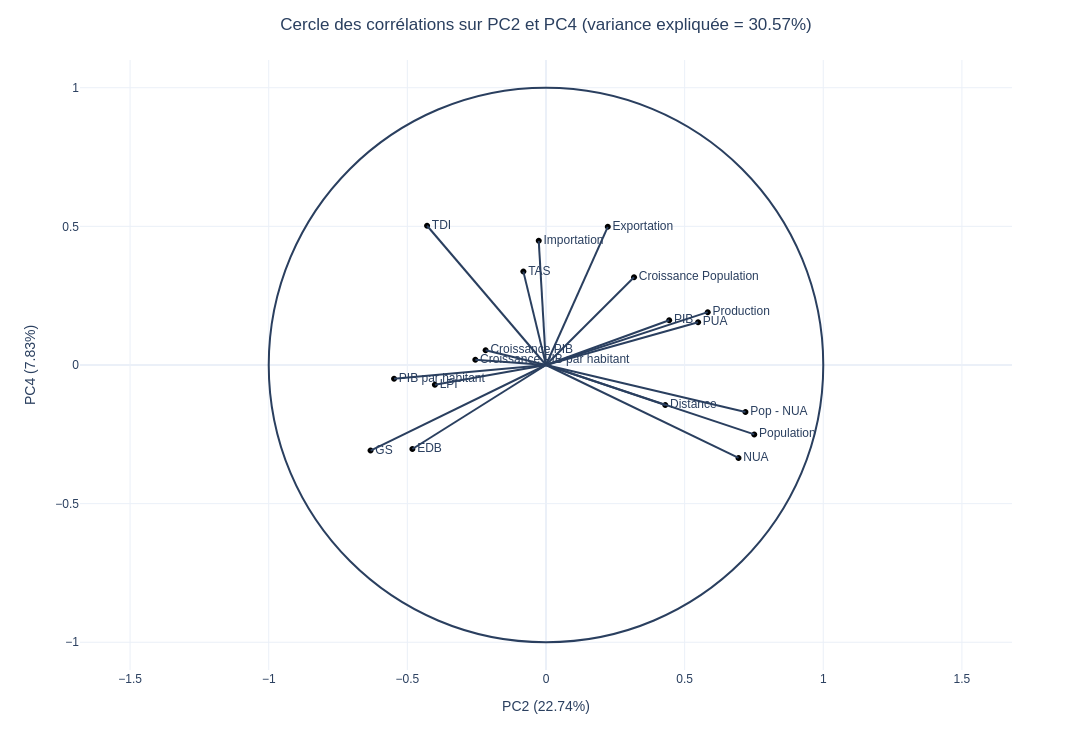

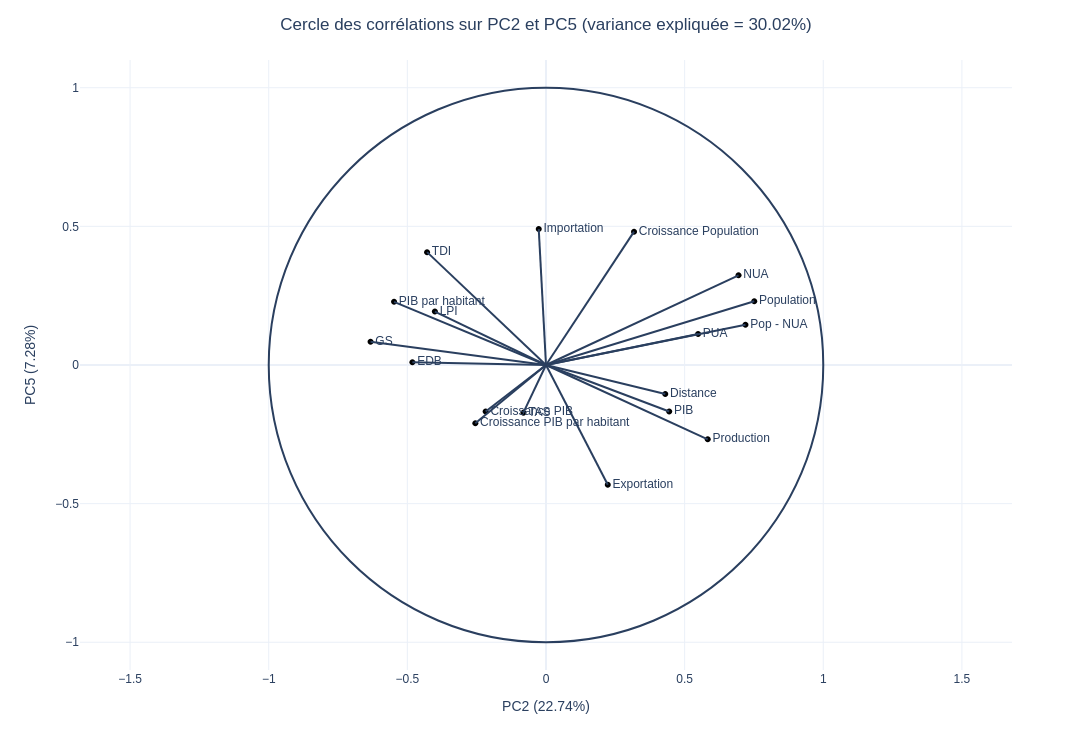

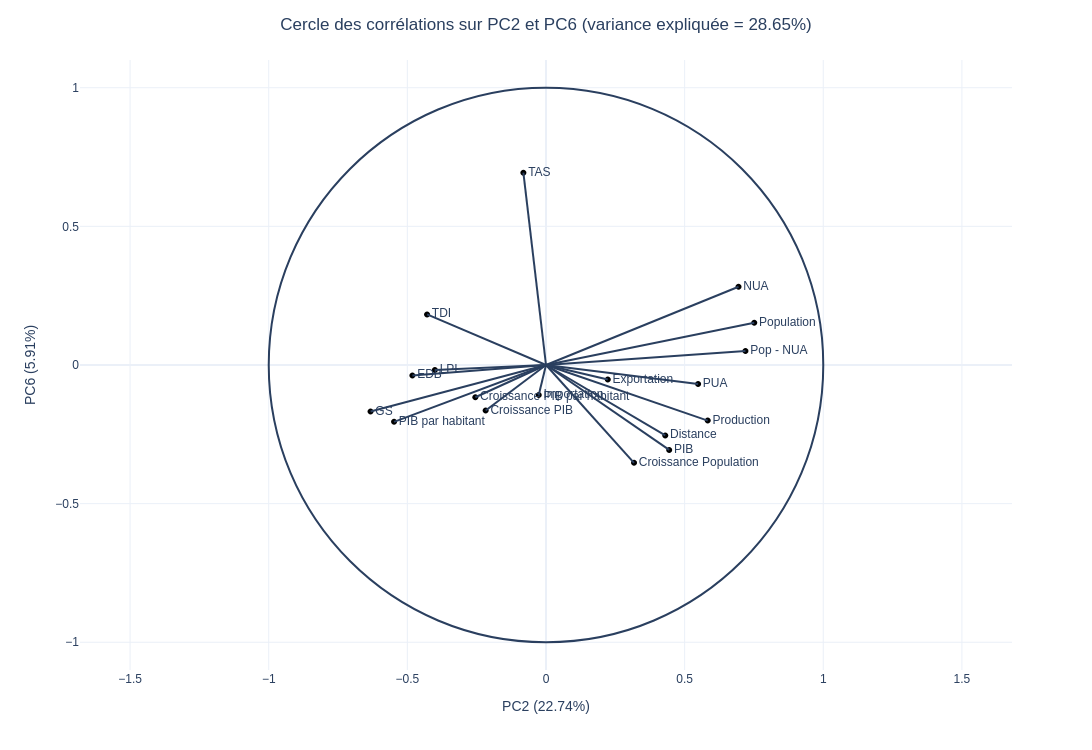

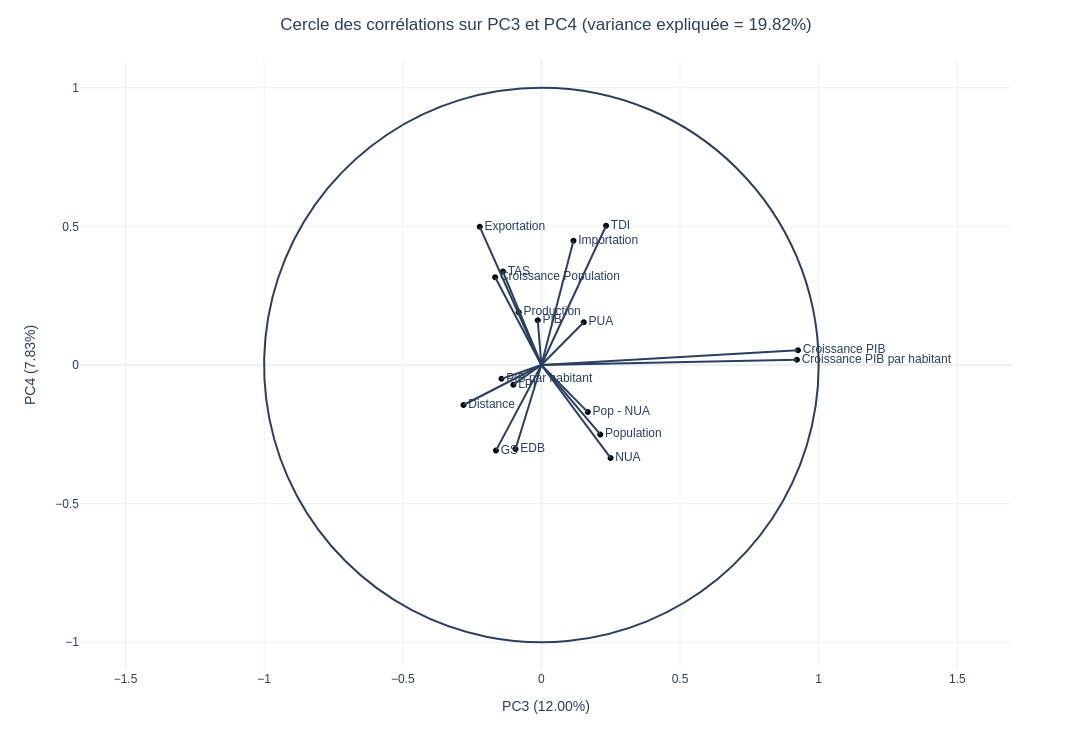

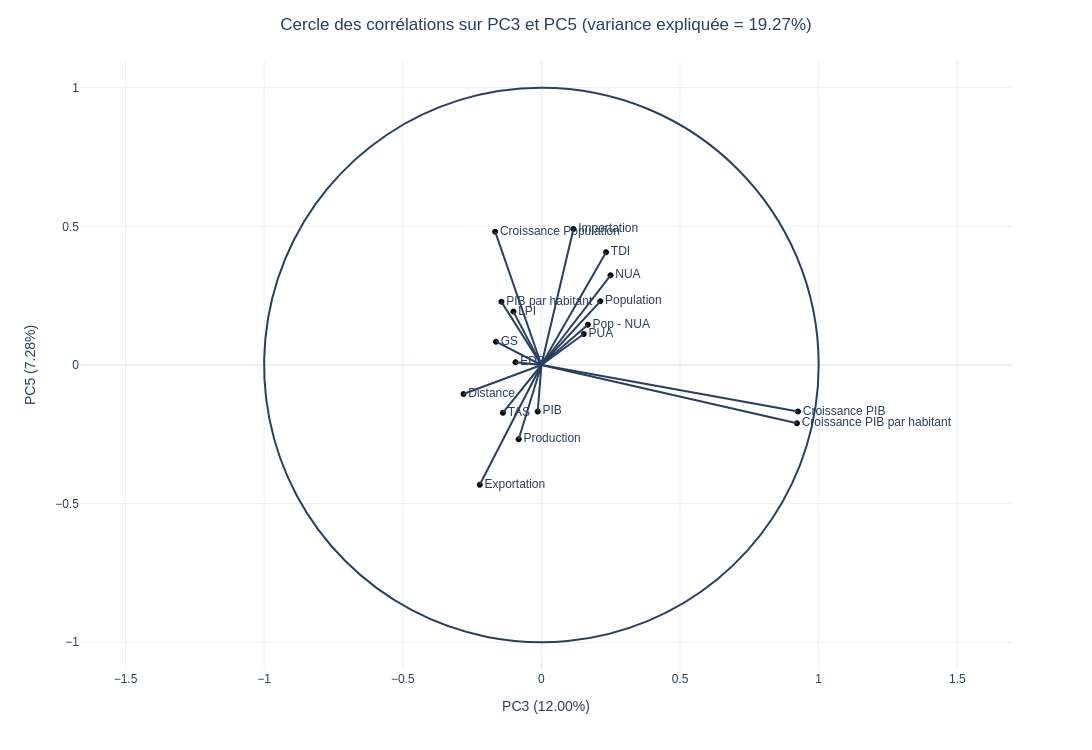

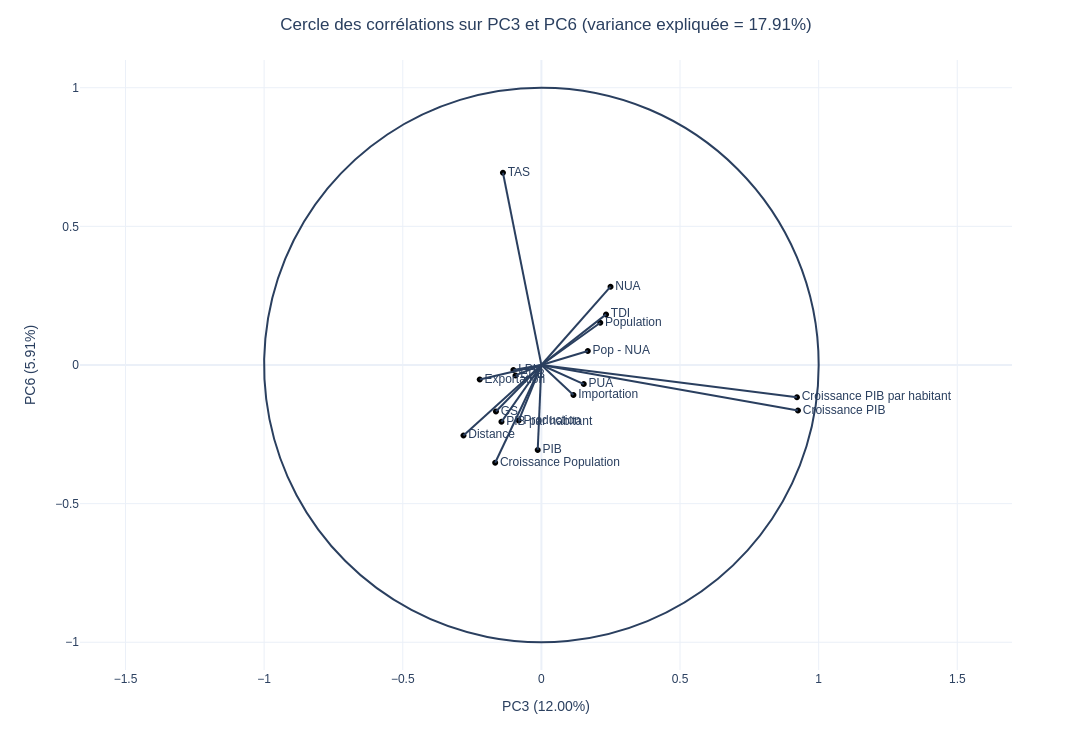

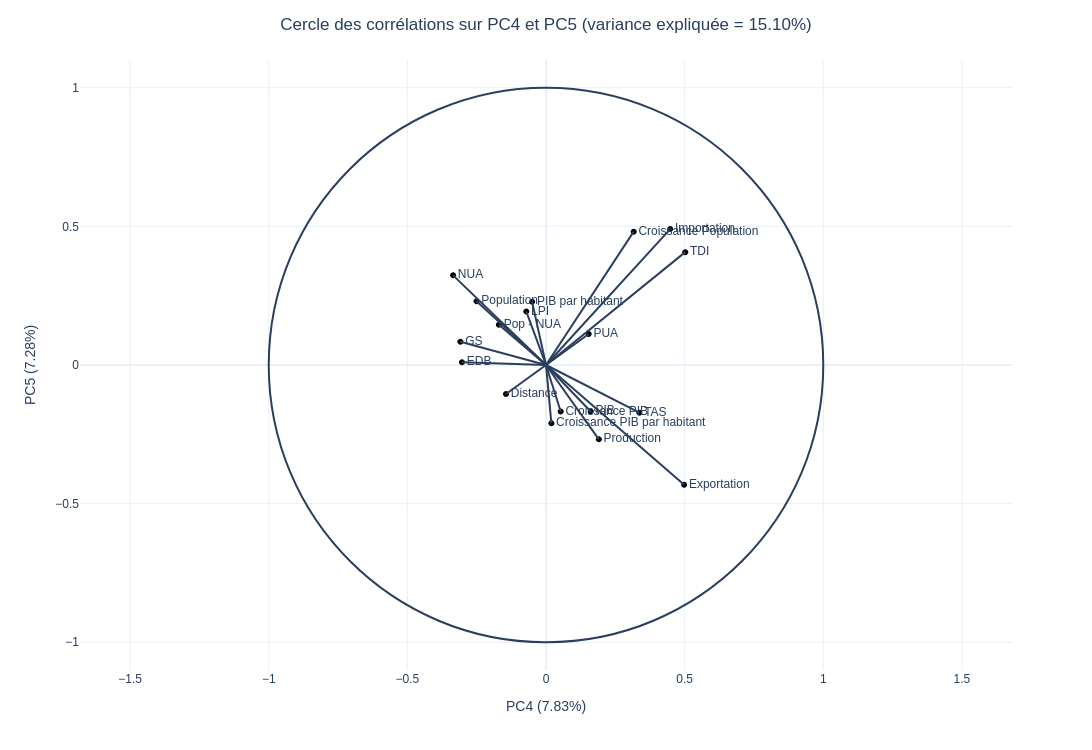

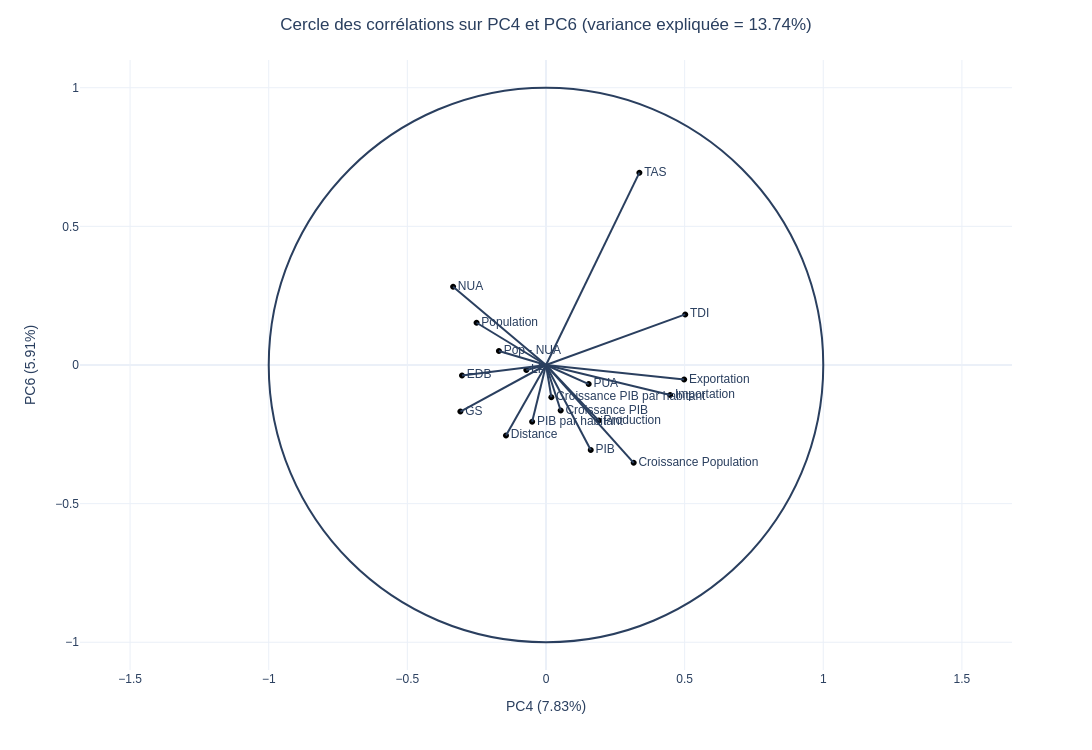

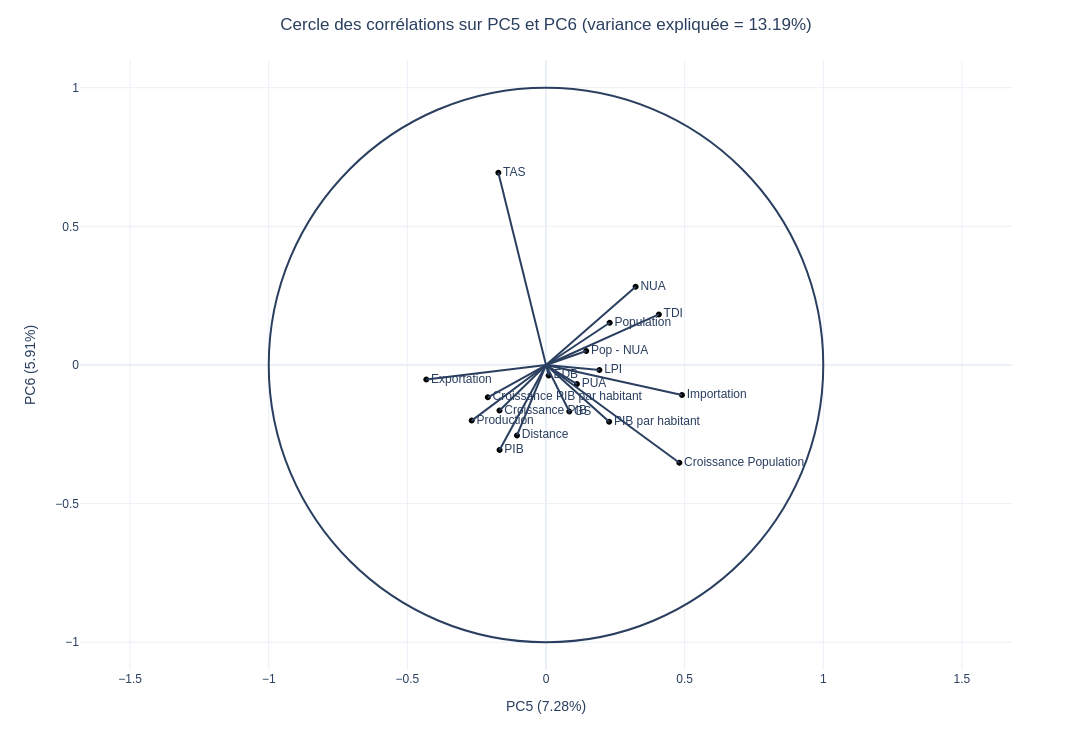

In [20]:
for i in range(6):
    for j in range(i+1, 6):
        correlation_circle(i+1, j+1)

In [21]:
def correlation_sphere(x: int, y: int, z: int):
    assert x in range(1, df_data_std.shape[1]+1), f"Illegal argument: x = {x}"
    assert y in range(1, df_data_std.shape[1]+1), f"Illegal argument: y = {y}"
    assert z in range(1, df_data_std.shape[1]+1), f"Illegal argument: z = {z}"
    assert len({ x, y, z }) == 3, "Illegal argument combination: not distinct"
    x = f"PC{x}"
    y = f"PC{y}"
    z = f"PC{z}"
    loadings = df_components.loc[[x,y,z]].T * np.sqrt(df_variance.loc[[x,y,z],"variance"])
    fig = px.scatter_3d(
        loadings, x=x, y=y, z=z, labels=labels, text=df_data_std.columns,
        color_discrete_sequence=["black"], template="plotly_white"
    )
    fig.update_traces(marker=dict(size=2))
    
    # Lines
    x_lines = []
    y_lines = []
    z_lines = []
    for feature in df_data_std.columns:
        x_lines.extend([ 0, loadings.loc[feature,x], None ])
        y_lines.extend([ 0, loadings.loc[feature,y], None ])
        z_lines.extend([ 0, loadings.loc[feature,z], None ])
    trace = go.Scatter3d(x=x_lines, y=y_lines, z=z_lines, mode="lines", name="Lignes", line_color="black")
    fig.add_trace(trace)
    
    # Sphere
    theta = np.linspace(0, 2*np.pi, 100)
    phi   = np.linspace(0,   np.pi, 100)
    x_sphere = np.outer(np.cos(theta), np.sin(phi))
    y_sphere = np.outer(np.sin(theta), np.sin(phi))
    z_sphere = np.outer(np.ones(100) , np.cos(phi))
    trace = go.Surface(x=x_sphere, y=y_sphere, z=z_sphere, colorscale="gray", name="Sphère")
    trace.update(showscale=False, showlegend=True, opacity=0.1, hoverinfo="skip")
    trace.update(contours=dict(x_highlight=False, y_highlight=False, z_highlight=False))
    fig.add_trace(trace)
    
    fig.update_layout(
        title=f"Sphère des corrélations sur {x}, {y} et {z} (variance expliquée = {df_variance.loc[[x,y,z],'variance_pct'].sum():.2%})",
        title_x=0.5,
    )
    fig.update_layout(width=1000, height=800)
    fig.update_layout(legend=dict(x=0.5, y=1, xanchor="center", yanchor="middle", orientation="h"))
    fig.show()

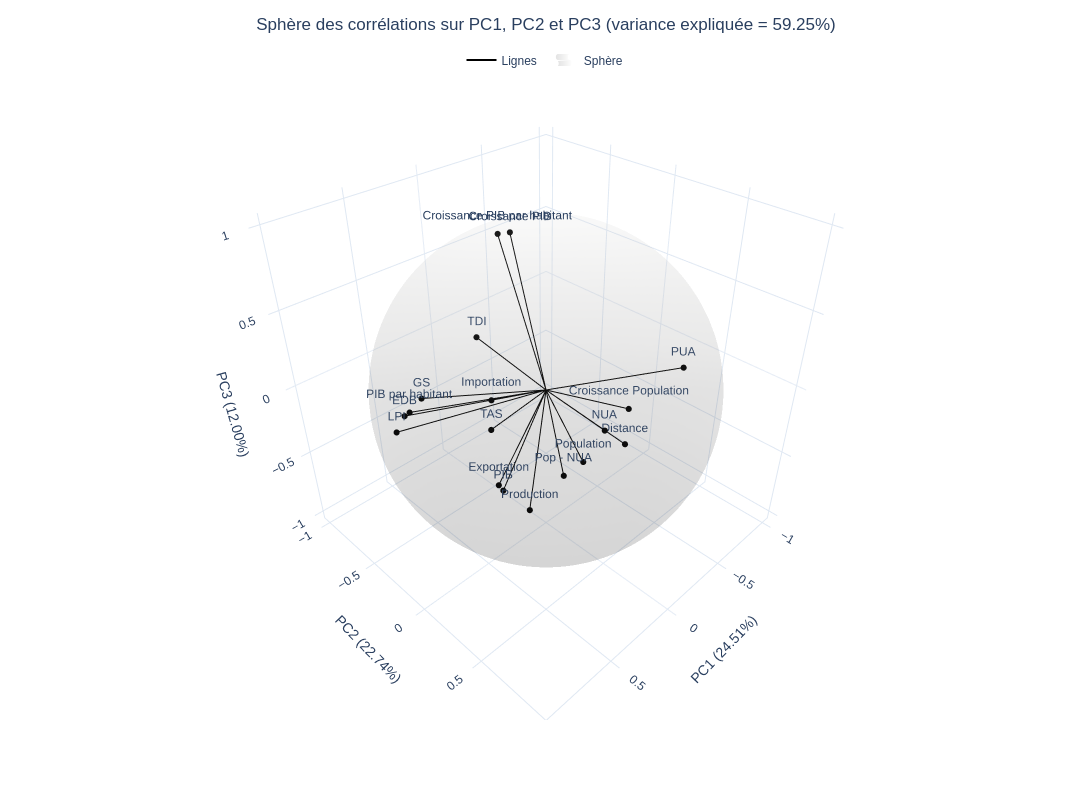

In [22]:
correlation_sphere(1, 2, 3)

# K-means

In [23]:
kmeans_l = [ KMeans(n_clusters=k, n_init=1000, init="random").fit(df_data_clustering) for k in range(2, 10) ]
print(*kmeans_l, sep="\n")

KMeans(init='random', n_clusters=2, n_init=1000)
KMeans(init='random', n_clusters=3, n_init=1000)
KMeans(init='random', n_clusters=4, n_init=1000)
KMeans(init='random', n_clusters=5, n_init=1000)
KMeans(init='random', n_clusters=6, n_init=1000)
KMeans(init='random', n_clusters=7, n_init=1000)
KMeans(init='random', n_init=1000)
KMeans(init='random', n_clusters=9, n_init=1000)


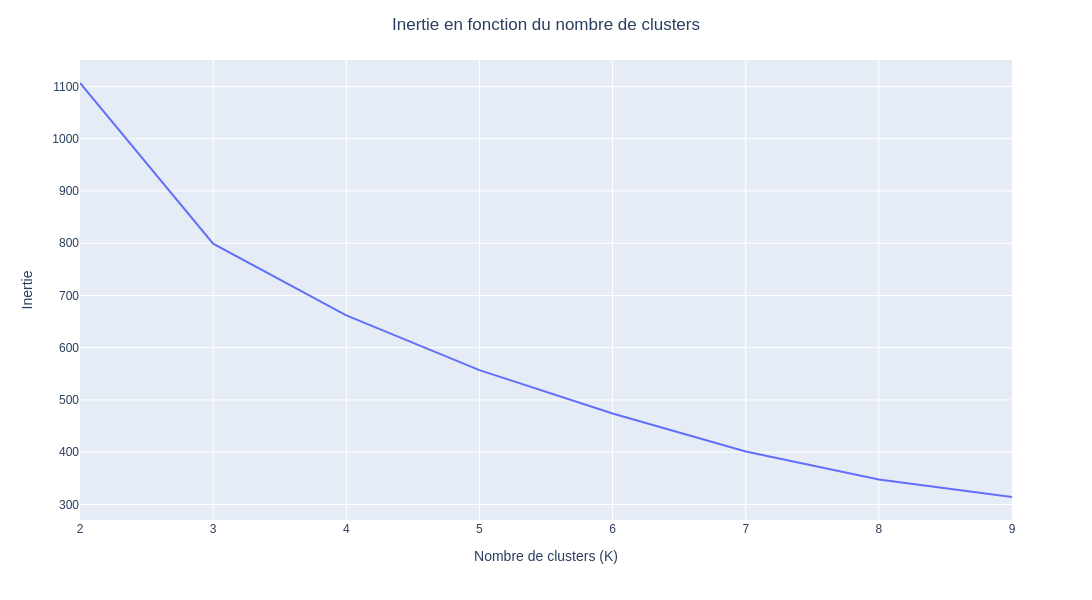

In [24]:
fig = px.line(
    x=[ kmeans.n_clusters for kmeans in kmeans_l ],
    y=[ kmeans.inertia_   for kmeans in kmeans_l ],
)
fig.update_layout(title="Inertie en fonction du nombre de clusters", title_x=0.5)
fig.update_layout(yaxis_title="Inertie", xaxis_title="Nombre de clusters (K)")
fig.update_layout(width=800, height=600)
fig.show()

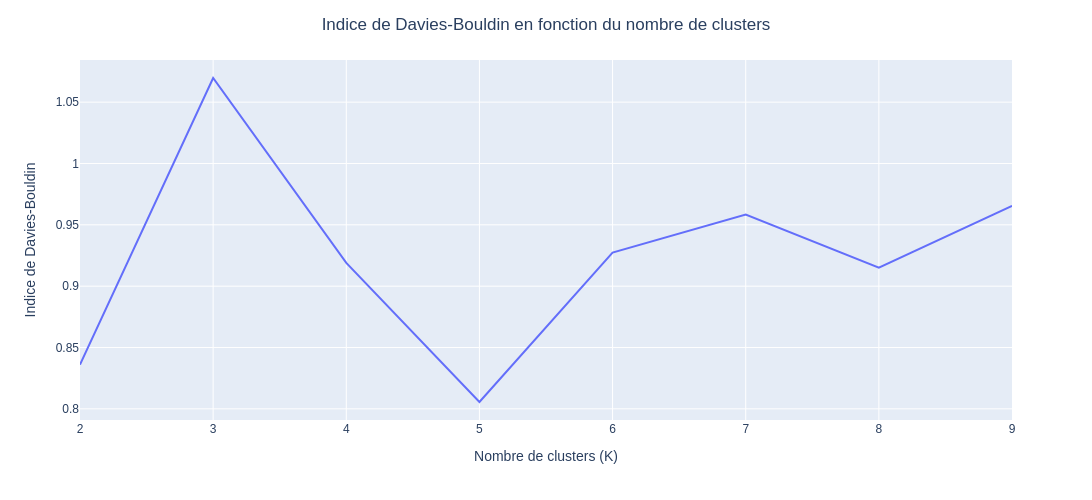

In [25]:
fig = px.line(
    x=[ kmeans.n_clusters for kmeans in kmeans_l ],
    y=[ davies_bouldin_score(df_data_clustering.to_numpy(), kmeans.labels_) for kmeans in kmeans_l ],
)
fig.update_layout(title="Indice de Davies-Bouldin en fonction du nombre de clusters", title_x=0.5)
fig.update_layout(yaxis_title="Indice de Davies-Bouldin", xaxis_title="Nombre de clusters (K)")
fig.update_layout(width=1000, height=500)
fig.show()

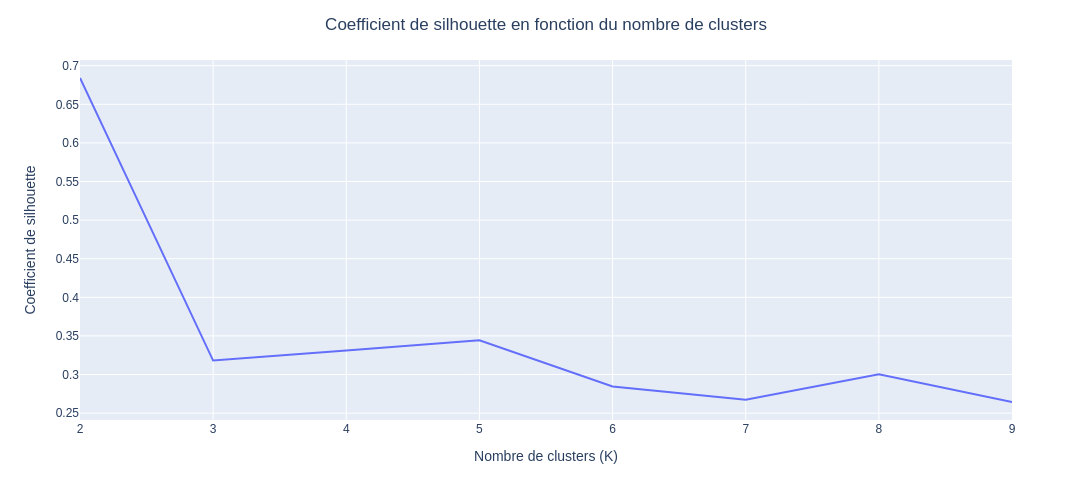

In [26]:
fig = px.line(
    x=[ kmeans.n_clusters for kmeans in kmeans_l ],
    y=[ silhouette_score(df_data_clustering.to_numpy(), kmeans.labels_) for kmeans in kmeans_l ],
)
fig.update_layout(title="Coefficient de silhouette en fonction du nombre de clusters", title_x=0.5)
fig.update_layout(yaxis_title="Coefficient de silhouette", xaxis_title="Nombre de clusters (K)")
fig.update_layout(width=1000, height=500)
fig.show()

L'indice de Davies-Bouldin varie entre 0 (meilleure classification) et $+\infty$ (pire classification).

Le coefficient de silhouette varie entre -1 (pire classification) et +1 (meilleure classification).

Le nombre de clusters **K=5** est recommandé par ces deux scores.

**Attention**  
L'initialisation de l'algorithme K-means est aléatoire (`init="random"`, impacte le choix des centroïdes initiaux).  
Grâce au paramètre `n_init=1000`, la partition trouvée est généralement stable (peut-être un minimum global = meilleur minimum local).  
En revanche, la numérotation des clusters peut varier.  
Il est possible de fixer le paramètre `random_state` pour garantir la reproductibilité.

Les blocs de code suivants permettent de définir une numérotation fixe des clusters basée sur les codes ISO3.
- Pour chaque cluster, parmi les pays qu'il contient, on retient le plus petit code ISO3 (au sens lexicographique).
- Les clusters sont triés selon l'ordre lexicographique croissant de ces codes ISO3 retenus.

In [27]:
cluster_kmeans_raw = kmeans_l[5-2].labels_
cluster_kmeans_raw

array([2, 3, 2, 3, 3, 0, 2, 3, 3, 3, 2, 4, 3, 3, 2, 1, 2, 2, 2, 2, 3, 3,
       3, 3, 2, 2, 2, 2, 3, 3, 3, 2, 3, 2, 3, 2, 2, 2, 3, 3, 2, 1, 3, 2,
       2, 3, 3, 3, 2, 2, 3, 2, 2, 3, 2, 2, 2, 2, 2, 3, 3, 3, 2, 3, 2, 3,
       3, 2, 2, 3, 3, 2, 2, 0, 3, 3, 2, 2, 2, 2, 3, 3, 2, 3, 2, 2, 3, 3,
       3, 2, 3, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2], dtype=int32)

In [28]:
df_cluster_kmeans = df_join.reset_index().groupby(cluster_kmeans_raw).agg({"ISO3":["count","min"]}).reset_index()
df_cluster_kmeans.columns = [ "raw", "size", "min ISO3" ]
df_cluster_kmeans.sort_values("min ISO3", inplace=True, ignore_index=True)
df_cluster_kmeans.index = (df_cluster_kmeans.index + 1).astype(str) # Enforce categorical
df_cluster_kmeans.index.name = "Cluster K-means"
df_cluster_kmeans

,raw,size,min ISO3
Cluster K-means,,,
1,2,53,AGO
2,3,42,ARE
3,0,2,BEL
4,4,2,BRA
5,1,2,CHN


In [29]:
sigma = df_cluster_kmeans["raw"].reset_index().set_index("raw")
sigma

,Cluster K-means
raw,
2,1
3,2
0,3
4,4
1,5


In [30]:
df_join["Cluster K-means"] = pd.Series(cluster_kmeans_raw, index=df_join.index).map(sigma["Cluster K-means"].loc.__getitem__)
df_join.reset_index().groupby("Cluster K-means").agg({"ISO3":["count","min"]})

ISO3     
                count  min
Cluster K-means           
1                  53  AGO
2                  42  ARE
3                   2  BEL
4                   2  BRA
5                   2  CHN

In [31]:
print()
for cluster, (raw, size, min_iso3) in df_cluster_kmeans.iterrows():
    zones = df_join[ (df_join["Cluster K-means"] == str(cluster)) ]["Zone"]
    print(f"Cluster #{cluster}: {size} pays")
    for zone in zones.sort_values():
        print("  -", zone)
    print()


Cluster #1: 53 pays
  - Afrique du Sud
  - Algérie
  - Angola
  - Arménie
  - Bangladesh
  - Bolivie (État plurinational de)
  - Chili
  - Colombie
  - Congo
  - Costa Rica
  - Côte d'Ivoire
  - Fidji
  - Ghana
  - Guatemala
  - Guyana
  - Honduras
  - Indonésie
  - Iran (République islamique d')
  - Iraq
  - Jamaïque
  - Jordanie
  - Kenya
  - Kirghizistan
  - Lesotho
  - Liban
  - Libéria
  - Maroc
  - Mexique
  - Mongolie
  - Myanmar
  - Niger
  - Nigéria
  - Ouganda
  - Ouzbékistan
  - Pakistan
  - Panama
  - Paraguay
  - Philippines
  - Pérou
  - Rwanda
  - République arabe syrienne
  - République dominicaine
  - République démocratique populaire lao
  - Sri Lanka
  - Sénégal
  - Trinité-et-Tobago
  - Tunisie
  - Türkiye
  - Uruguay
  - Viet Nam
  - Zambie
  - Égypte
  - Équateur

Cluster #2: 42 pays
  - Allemagne
  - Australie
  - Autriche
  - Bosnie-Herzégovine
  - Bulgarie
  - Bélarus
  - Canada
  - Chypre
  - Croatie
  - Danemark
  - Espagne
  - Estonie
  - Finlande
  - Fédér

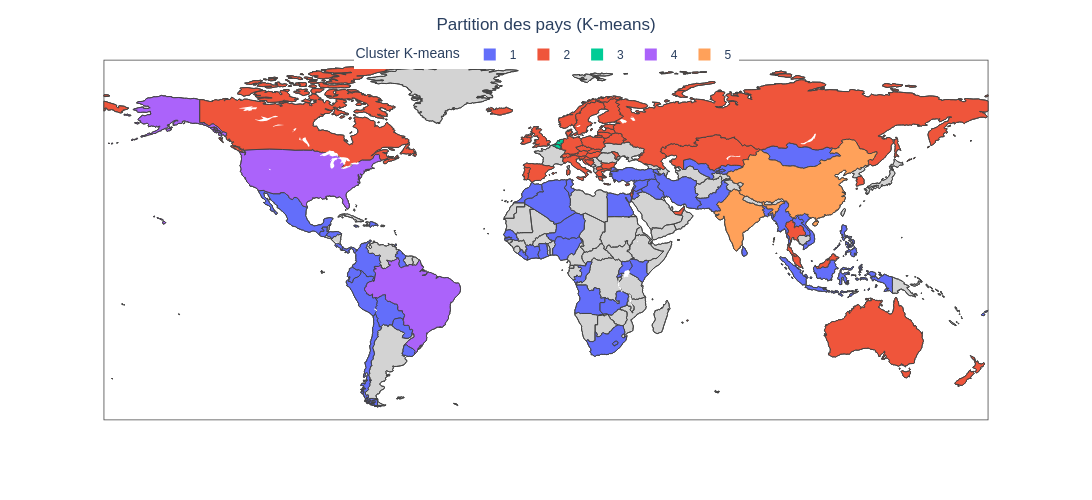

In [32]:
fig = px.choropleth(
    df_join, locations=df_join.index, color="Cluster K-means", hover_name="Zone",
    category_orders={"Cluster K-means":df_cluster_kmeans.index}, width=1000, height=500,
)
fig.update_geos(showcountries=True, landcolor="lightgray", lataxis_range=(-55,80)) # Hide poles
fig.update_layout(legend=dict(x=0.5, y=0.975, xanchor="center", yanchor="bottom", orientation="h"))
fig.update_layout(title="Partition des pays (K-means)", title_x=0.5)
fig.show()

# Classification Hiérarchique

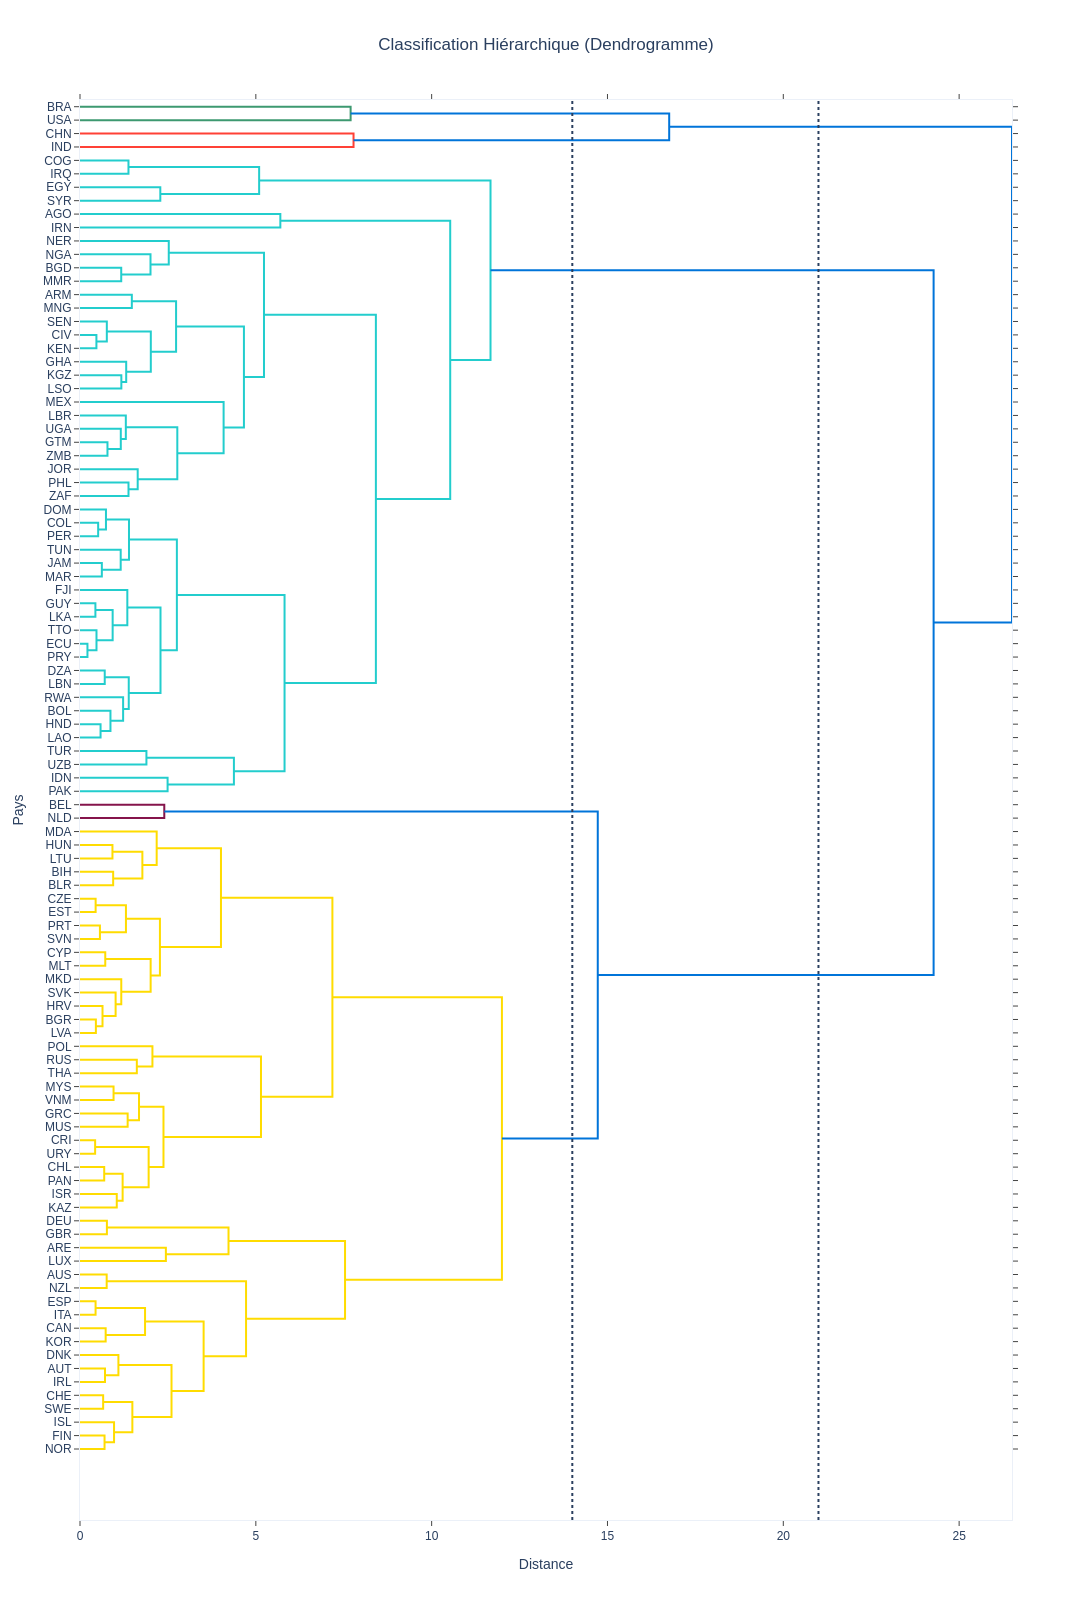

In [33]:
fig = create_dendrogram(
    df_data_clustering, orientation="left", labels=df_data.index, # labels=df_data["Zone"].to_numpy(),
    linkagefun=ward, color_threshold=14,
)
fig.add_vline(x=14, line_dash="dot", line_width=2)
fig.add_vline(x=21, line_dash="dot", line_width=2)
fig.update_layout(width=800, height=1600, template="plotly_white")
fig.update_layout(title="Classification Hiérarchique (Dendrogramme)", title_x=0.5)
fig.update_layout(xaxis_title="Distance", yaxis_title="Pays")
fig.show()

Comme précédemment avec l'algorithme K-means, les clusters sont renumérotés par code ISO3 minimal (au sens lexicographique).

In [34]:
cluster_ch_raw = fcluster(ward(df_data_clustering), 14, criterion="distance")
cluster_ch_raw

array([3, 5, 3, 5, 5, 4, 3, 5, 5, 5, 3, 1, 5, 5, 5, 2, 3, 3, 3, 5, 5, 5,
       5, 5, 3, 3, 3, 3, 5, 5, 5, 3, 5, 3, 5, 3, 3, 3, 5, 5, 3, 2, 5, 3,
       3, 5, 5, 5, 3, 3, 5, 3, 3, 5, 3, 3, 3, 3, 3, 5, 5, 5, 3, 5, 3, 5,
       5, 3, 3, 5, 5, 3, 3, 4, 5, 5, 3, 5, 3, 3, 5, 5, 3, 5, 3, 3, 5, 5,
       5, 3, 5, 3, 3, 3, 3, 5, 1, 3, 5, 3, 3], dtype=int32)

In [35]:
df_cluster_ch = df_join.reset_index().groupby(cluster_ch_raw).agg({"ISO3":["count","min"]}).reset_index()
df_cluster_ch.columns = [ "raw", "size", "min ISO3" ]
df_cluster_ch.sort_values("min ISO3", inplace=True, ignore_index=True)
df_cluster_ch.index = (df_cluster_ch.index + 1).astype(str) # Enforce categorical
df_cluster_ch.index.name = "Cluster CH"
df_cluster_ch

,raw,size,min ISO3
Cluster CH,,,
1,3,48,AGO
2,5,47,ARE
3,4,2,BEL
4,1,2,BRA
5,2,2,CHN


In [36]:
sigma = df_cluster_ch["raw"].reset_index().set_index("raw")
sigma

,Cluster CH
raw,
3,1
5,2
4,3
1,4
2,5


In [37]:
df_join["Cluster CH"] = pd.Series(cluster_ch_raw, index=df_join.index).map(sigma["Cluster CH"].loc.__getitem__)
df_join.reset_index().groupby("Cluster CH").agg({"ISO3":["count","min"]})

ISO3     
           count  min
Cluster CH           
1             48  AGO
2             47  ARE
3              2  BEL
4              2  BRA
5              2  CHN

In [38]:
print()
for cluster, (raw, size, min_iso3) in df_cluster_ch.iterrows():
    zones = df_join[ (df_join["Cluster CH"] == str(cluster)) ]["Zone"]
    print(f"Cluster #{cluster}: {size} pays")
    for zone in zones.sort_values():
        print("  -", zone)
    print()


Cluster #1: 48 pays
  - Afrique du Sud
  - Algérie
  - Angola
  - Arménie
  - Bangladesh
  - Bolivie (État plurinational de)
  - Colombie
  - Congo
  - Côte d'Ivoire
  - Fidji
  - Ghana
  - Guatemala
  - Guyana
  - Honduras
  - Indonésie
  - Iran (République islamique d')
  - Iraq
  - Jamaïque
  - Jordanie
  - Kenya
  - Kirghizistan
  - Lesotho
  - Liban
  - Libéria
  - Maroc
  - Mexique
  - Mongolie
  - Myanmar
  - Niger
  - Nigéria
  - Ouganda
  - Ouzbékistan
  - Pakistan
  - Paraguay
  - Philippines
  - Pérou
  - Rwanda
  - République arabe syrienne
  - République dominicaine
  - République démocratique populaire lao
  - Sri Lanka
  - Sénégal
  - Trinité-et-Tobago
  - Tunisie
  - Türkiye
  - Zambie
  - Égypte
  - Équateur

Cluster #2: 47 pays
  - Allemagne
  - Australie
  - Autriche
  - Bosnie-Herzégovine
  - Bulgarie
  - Bélarus
  - Canada
  - Chili
  - Chypre
  - Costa Rica
  - Croatie
  - Danemark
  - Espagne
  - Estonie
  - Finlande
  - Fédération de Russie
  - Grèce
  - Hongri

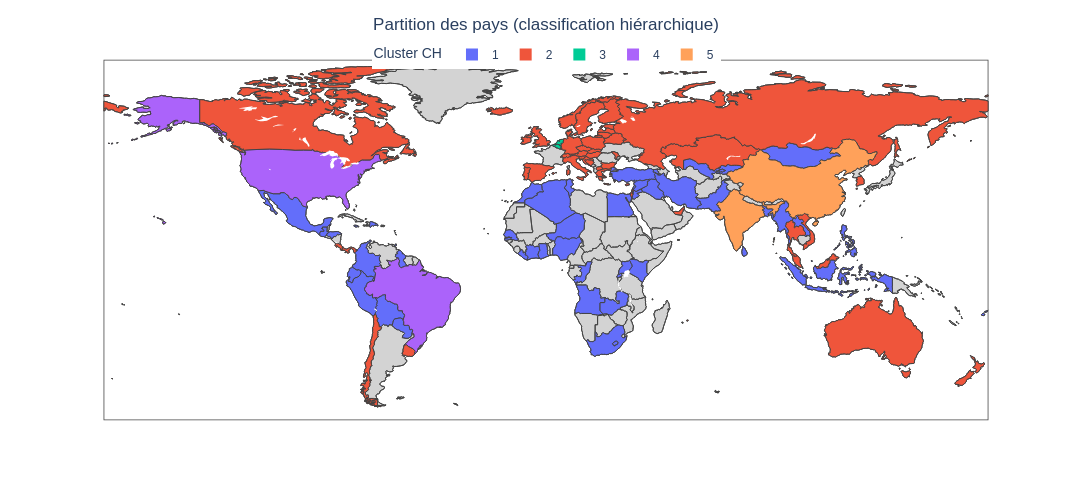

In [39]:
fig = px.choropleth(
    df_join, locations=df_join.index, color="Cluster CH", hover_name="Zone",
    category_orders={"Cluster CH":df_cluster_ch.index}, width=1000, height=500,
)
fig.update_geos(showcountries=True, landcolor="lightgray", lataxis_range=(-55,80)) # Hide poles
fig.update_layout(legend=dict(x=0.5, y=0.975, xanchor="center", yanchor="bottom", orientation="h"))
fig.update_layout(title="Partition des pays (classification hiérarchique)", title_x=0.5)
fig.show()

# Différences entre les deux classifications

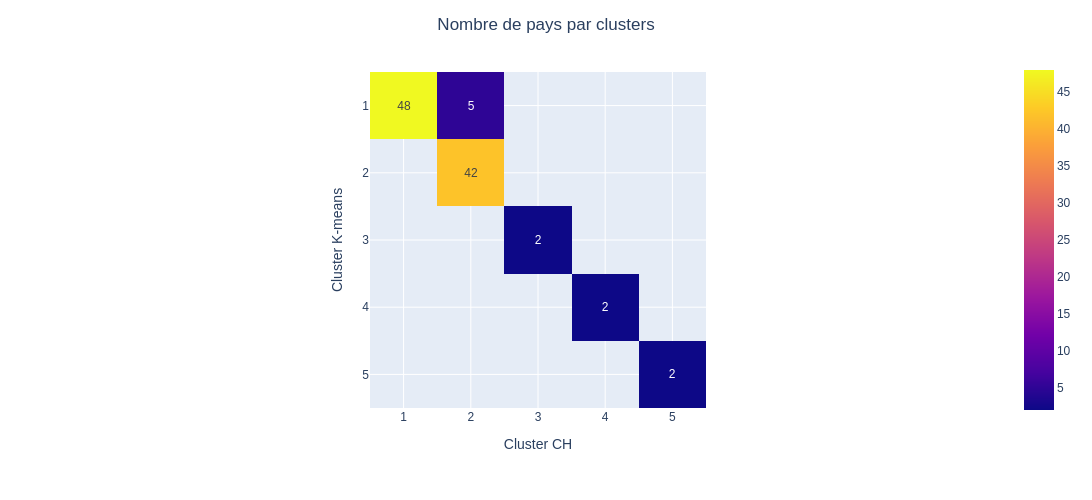

In [40]:
fig = px.imshow(
    pd.crosstab(df_join["Cluster K-means"], df_join["Cluster CH"], dropna=False).replace(0, None),
    text_auto=True,
)
# fig.update_xaxes(side="top")
fig.update_layout(title="Nombre de pays par clusters", title_x=0.5, width=500, height=500)
fig.show()

In [41]:
print(f"Indice de Rand = {rand_score(df_join["Cluster K-means"], df_join["Cluster CH"]):.2%}")

Indice de Rand = 91.09%


In [42]:
df_diff = df_data[ (df_join["Cluster K-means"] != df_join["Cluster CH"]) ]
df_diff

,Zone,Production,Importation,Exportation,TDI,TAS,Population,Croissance Population,Croissance PIB,Croissance PIB par habitant,PIB,PIB par habitant,NUA,Pop - NUA,PUA,GS,LPI,EDB,Distance
ISO3,,,,,,,,,,,,,,,,,,,
CHL,Chili,762.0,160.0,157.0,0.209150,0.996078,18893191.0,12.199088,6.888612,4.997170,295402.646018,15635.402512,8700000.0,10193191.0,46.0,77.410953,3.32,72.32025,11663.390
CRI,Costa Rica,136.0,15.0,3.0,0.101351,0.918919,4957818.0,11.661159,3.146472,2.217724,62420.164965,12590.249373,800000.0,4157818.0,15.3,76.735494,2.79,68.83187,8919.449
PAN,Panama,209.0,21.0,1.0,0.091703,0.912664,4167860.0,19.059671,4.723616,2.986033,67294.200000,16145.981853,1700000.0,2467860.0,40.6,72.117442,3.28,66.86797,8671.104
URY,Uruguay,32.0,6.0,3.0,0.171429,0.914286,3394534.0,2.796852,0.520538,0.340006,65344.413974,19249.892319,1100000.0,2294534.0,32.3,84.906645,2.69,61.36826,10972.420
VNM,Viet Nam,930.0,162.0,22.0,0.151402,0.869159,96237319.0,12.986708,10.219479,9.005081,310106.478468,3222.310015,10500000.0,85737319.0,10.9,64.967558,3.27,68.56869,9208.554


In [43]:
df_join[ (df_join["Cluster K-means"] != df_join["Cluster CH"]) ][["Cluster K-means","Cluster CH"]]

,Cluster K-means,Cluster CH
ISO3,,
CHL,1,2
CRI,1,2
PAN,1,2
URY,1,2
VNM,1,2


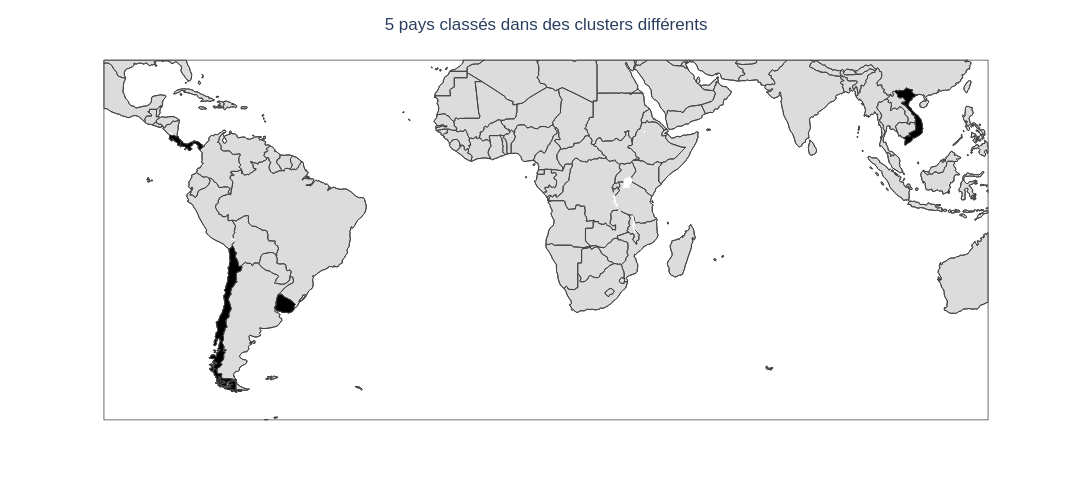

In [44]:
fig = px.choropleth(
    df_diff, locations=df_diff.index, hover_name="Zone",
    color_discrete_sequence=["Black"], width=1000, height=500,
)
fig.update_geos(showcountries=True, fitbounds="locations", landcolor="Gainsboro", lataxis_range=(-55,80)) # Hide poles
fig.update_layout(title=f"{df_diff.shape[0]} pays classés dans des clusters différents", title_x=0.5, showlegend=False)
fig.show()

# Projection des clusters sur les plans factoriels

## Projection 2D

In [45]:
def pca_display_2d_combinations(n: int, color: str|None = None):
    assert n > 0, f"Illegal argument: n = {n}"
    assert color in (None, "Cluster CH", "Cluster K-means"), f"Bad column name: color = {color}"
    fig = px.scatter_matrix(
        df_join, dimensions=[ f"PC{i+1}" for i in range(n) ], labels=labels,
        color=color, category_orders={"Cluster CH":df_cluster_ch.index,"Cluster K-means":df_cluster_kmeans.index},
        hover_name=df_data["Zone"], hover_data=df_data_std.columns,
    )
    fig.update_traces(diagonal_visible=False, showupperhalf=False)
    fig.update_layout(width=1000, height=800, showlegend=False)
    fig.show()

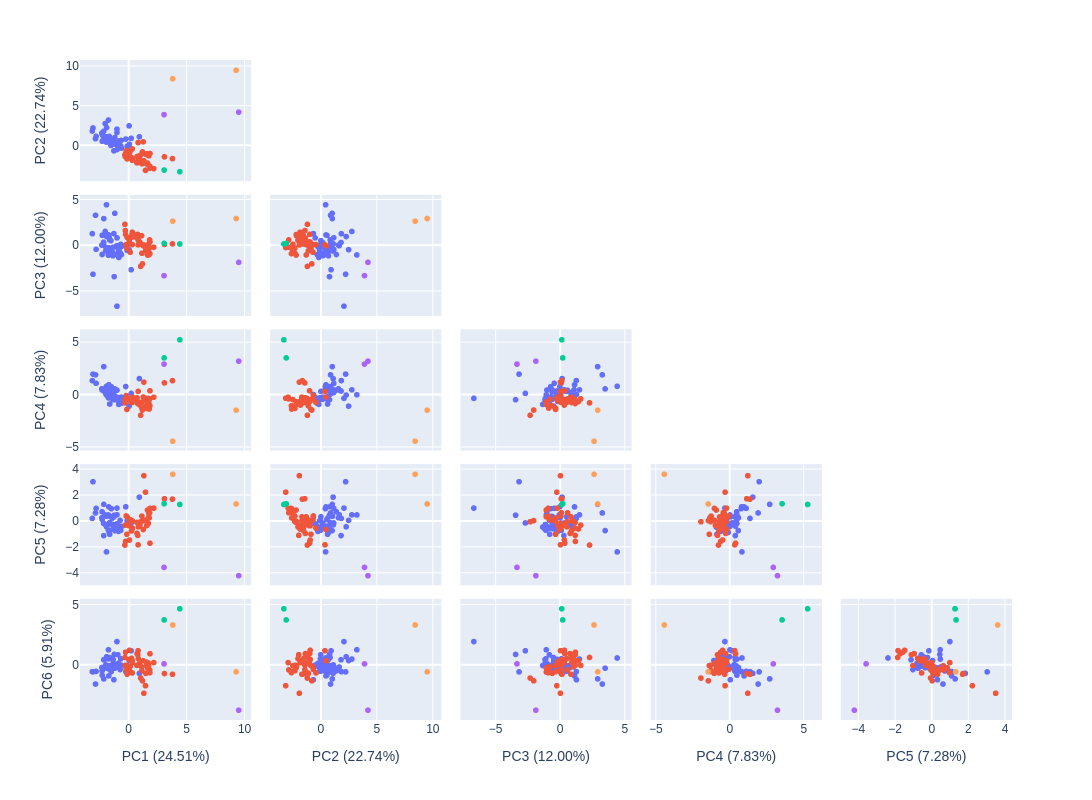

In [46]:
pca_display_2d_combinations(6, "Cluster K-means")

In [47]:
def pca_display_2d(x: int, y: int, color: str|None = None):
    assert x in range(1, df_data_std.shape[1]+1), "Illegal argument: x = {x}"
    assert y in range(1, df_data_std.shape[1]+1), "Illegal argument: y = {y}"
    assert len({ x, y }) == 2, "Illegal argument combination: not distinct"
    assert color in (None, "Cluster CH", "Cluster K-means"), f"Bad column name: color = {color}"
    x = f"PC{x}"
    y = f"PC{y}"
    fig = px.scatter(
        df_join, x=x, y=y, labels=labels, hover_name=df_join["Zone"], hover_data=df_data.columns,
        color=color, category_orders={"Cluster CH":df_cluster_ch.index,"Cluster K-means":df_cluster_kmeans.index},
    )
    fig.update_layout(
        title=f"Projection 2D sur {x} et {y} (variance expliquée = {df_variance.loc[[x,y],'variance_pct'].sum():.2%})",
        title_x=0.5, width=1000, height=600, showlegend=False,
        xaxis_dtick=2, yaxis_dtick=2, yaxis_scaleanchor="x", yaxis_scaleratio=1,
    )
    fig.show()

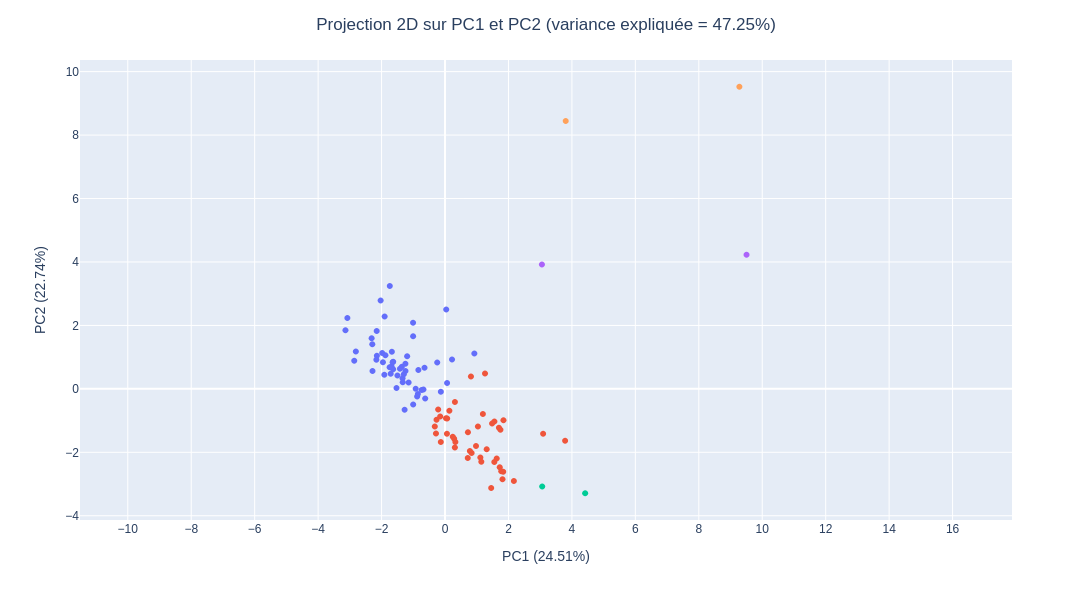

In [48]:
pca_display_2d(1, 2, "Cluster K-means")

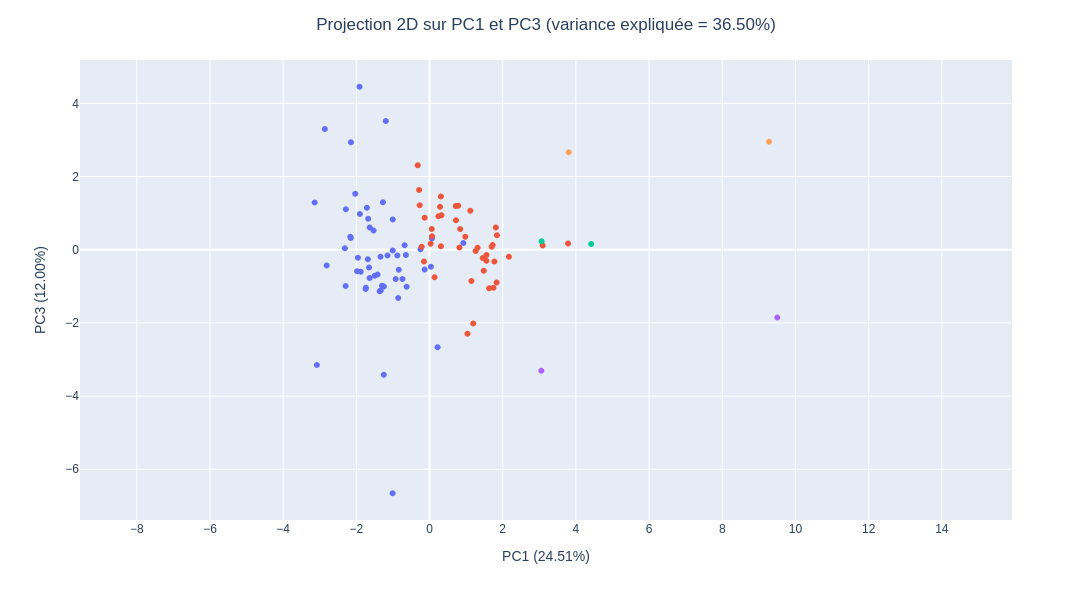

In [49]:
pca_display_2d(1, 3, "Cluster K-means")

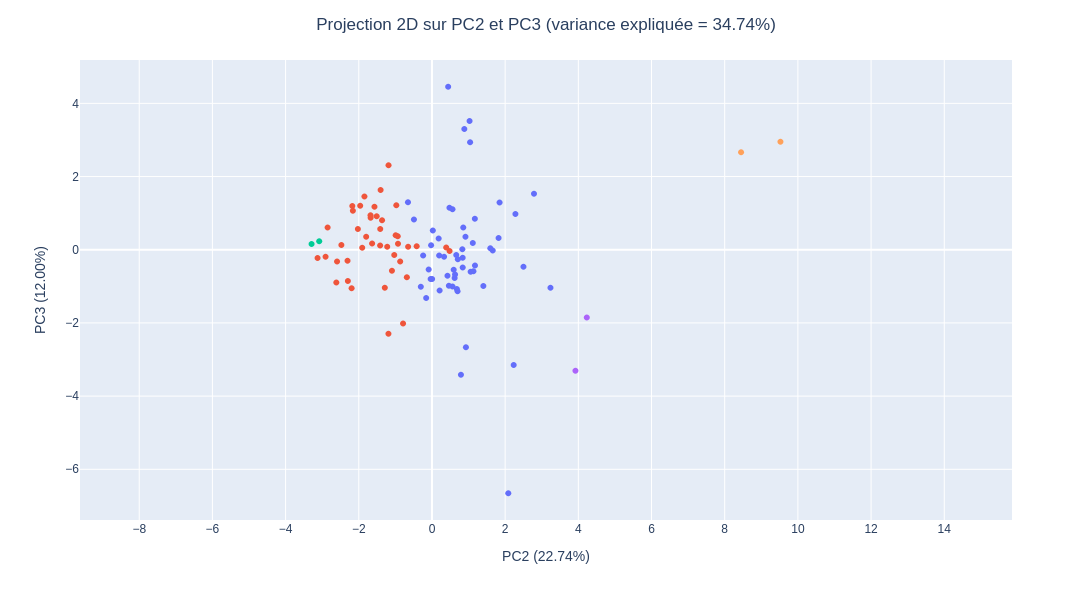

In [50]:
pca_display_2d(2, 3, "Cluster K-means")

## Projection 3D

In [51]:
def pca_display_3d(x: int, y: int, z: int, color: str|None = None):
    assert x in range(1, df_data_std.shape[1]+1), f"Illegal argument: x = {x}"
    assert y in range(1, df_data_std.shape[1]+1), f"Illegal argument: y = {y}"
    assert z in range(1, df_data_std.shape[1]+1), f"Illegal argument: z = {z}"
    assert len({ x, y, z }) == 3, "Illegal argument combination: not distinct"
    assert color in (None, "Cluster CH", "Cluster K-means"), f"Bad column name: color = {color}"
    x = f"PC{x}"
    y = f"PC{y}"
    z = f"PC{z}"
    fig = px.scatter_3d(
        df_join, x=x, y=y, z=z, labels=labels, hover_name=df_data["Zone"], hover_data=df_data.columns,
        color=color, category_orders={"Cluster CH":df_cluster_ch.index,"Cluster K-means":df_cluster_kmeans.index},
    )
    fig.update_layout(
        title=f"Projection 3D sur {x}, {y} et {z} (variance expliquée = {df_variance.loc[[x,y,z],"variance_pct"].sum():.2%})",
        title_x=0.5, width=1000, height=800, showlegend=False,
    )
    fig.update_traces(marker=dict(size=2))
    fig.show()

In [52]:
pca_display_3d(1, 2, 3, "Cluster K-means")